In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import random
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.preprocessing import StandardScaler , LabelEncoder
from tqdm import tqdm

In [ ]:
DATA_DIR = "/content/drive/MyDrive/data/super-ai-engineer-ss-6-sleep-stage-classification/train/train"

csv_files = glob(os.path.join(DATA_DIR, "*.csv"))
print(f"found :  {len(csv_files)} files")

found :  83 files


In [ ]:
def preprocess_time_series_with_fft(files, is_training=True, window_size=480):
    feature_segments = []
    label_segments = [] if is_training else None

    stage_mapping = {"W": 0, "R": 1, "N1": 2, "N2": 3, "N3": 4}

    for file in tqdm(files, desc="Processing Files"):
        df = pd.read_csv(file)

        if is_training and 'Sleep_Stage' in df.columns:
            label_data = df['Sleep_Stage'].map(stage_mapping).values
            df = df.drop(columns=['Sleep_Stage'])

        num_windows = len(df) // window_size

        def apply_fft(data):
            fft_data = np.fft.fft(data, axis=0)
            return np.abs(fft_data)

        segment_data = df.values[:num_windows * window_size].reshape(num_windows, window_size, -1)
        fft_segments = np.apply_along_axis(apply_fft, axis=1, arr=segment_data)
        feature_segments.append(fft_segments)

        if is_training:
            window_labels = label_data[:num_windows * window_size].reshape(num_windows, window_size)
            window_labels = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=1, arr=window_labels)
            label_segments.append(window_labels)

    X_output = np.vstack(feature_segments)
    y_output = np.hstack(label_segments) if is_training else None

    return (X_output, y_output) if is_training else X_output

In [ ]:
# Load train data (480-row segments)
X_train, y_train_notencoded = preprocess_time_series_with_fft(csv_files, is_training=True, window_size=480)

# Normalize each feature
scaler = StandardScaler()
label_encoder = LabelEncoder()

X_train_shape = X_train.shape
# Reshape to 2D for scaling (batch * timesteps, features)
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train_shape)
y_train = label_encoder.fit_transform(y_train_notencoded)

print("Data processing complete!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Processing Files: 100%|██████████| 83/83 [04:08<00:00,  3.00s/it]


Data processing complete!
X_train shape: (66745, 480, 8), y_train shape: (66745,)


In [ ]:
from collections import Counter

y_train

count = Counter(y_train)

print(count)

Counter({np.int64(3): 33786, np.int64(0): 15828, np.int64(2): 7753, np.int64(1): 7033, np.int64(4): 2345})


In [ ]:
X_train[0]

array([[ 5.27893380e-01,  1.02314459e+01,  4.09700955e+01, ...,
         4.64326080e-01,  2.47037707e+01,  2.22435214e+01],
       [ 4.98595818e-01,  1.32495308e+00,  3.42581965e-01, ...,
        -1.81837590e-02,  3.18772112e-01,  3.87649416e-01],
       [ 3.44993398e-01,  3.85507875e-01,  7.77512392e-02, ...,
        -2.00910323e-02,  1.57306492e-01,  3.12477521e-01],
       ...,
       [ 1.61807929e+00,  4.42668321e-01,  5.46759726e-02, ...,
        -1.93638736e-02,  9.33287820e-02,  2.02873691e-01],
       [ 3.44993398e-01,  3.85507875e-01,  7.77512392e-02, ...,
        -2.00910323e-02,  1.57306492e-01,  3.12477521e-01],
       [ 4.98595818e-01,  1.32495308e+00,  3.42581965e-01, ...,
        -1.81837590e-02,  3.18772112e-01,  3.87649416e-01]])

In [ ]:
X_train

array([[[ 5.27893380e-01,  1.02314459e+01,  4.09700955e+01, ...,
          4.64326080e-01,  2.47037707e+01,  2.22435214e+01],
        [ 4.98595818e-01,  1.32495308e+00,  3.42581965e-01, ...,
         -1.81837590e-02,  3.18772112e-01,  3.87649416e-01],
        [ 3.44993398e-01,  3.85507875e-01,  7.77512392e-02, ...,
         -2.00910323e-02,  1.57306492e-01,  3.12477521e-01],
        ...,
        [ 1.61807929e+00,  4.42668321e-01,  5.46759726e-02, ...,
         -1.93638736e-02,  9.33287820e-02,  2.02873691e-01],
        [ 3.44993398e-01,  3.85507875e-01,  7.77512392e-02, ...,
         -2.00910323e-02,  1.57306492e-01,  3.12477521e-01],
        [ 4.98595818e-01,  1.32495308e+00,  3.42581965e-01, ...,
         -1.81837590e-02,  3.18772112e-01,  3.87649416e-01]],

       [[ 4.78998940e-01,  1.14519100e+01,  4.07404572e+01, ...,
          4.61066306e-01,  2.67804145e+01,  2.17688975e+01],
        [ 5.15179225e-01,  3.27691703e-01,  7.38012255e-02, ...,
         -1.85730461e-02,  2.31738306e

Randomly selected sample index: 36648


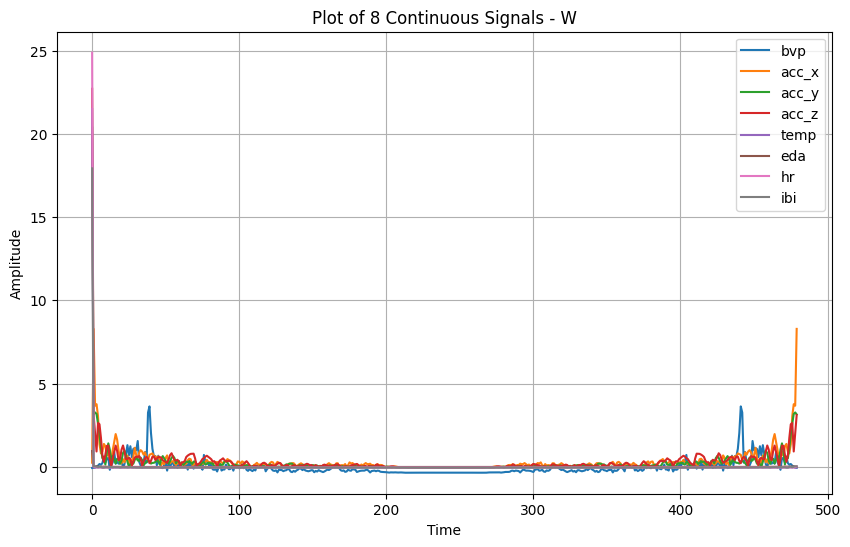

In [ ]:
import random

# สมมติว่า activity_map และ y_train ถูกกำหนดไว้แล้ว
activity_map = {
    0: "W",  # N: Nap
    1: "R",
    2: "N1",
    3: "N2",  # R: Rest
    4: "N3",  # W: Wake

}

# Generate a random sample index
sample_index = random.randint(0, len(y_train) - 1)  # Random index within the dataset
print(f"Randomly selected sample index: {sample_index}")

# Extract signal for the sample
signal_array = X_train[sample_index]  # Get the signal for the selected sample
time = np.arange(signal_array.shape[0])  # Time axis

# Get activity label and its name
activity_label = int(y_train[sample_index])  # Activity label for the sample
activity_name = activity_map[activity_label]

# Define the signal names (order must match the columns in the data)
signals = ['bvp', 'acc_x', 'acc_y', 'acc_z', 'temp', 'eda', 'hr', 'ibi']

# Plot the signals
plt.figure(figsize=(10, 6))
for i in range(signal_array.shape[1]):
    plt.plot(time, signal_array[:, i], label=f'{signals[i]}')

# Add labels, title, legend, and grid
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f'Plot of 8 Continuous Signals - {activity_name}')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy


In [ ]:
def f1_weighted(y_true, y_pred):
    num_classes = K.int_shape(y_pred)[-1]
    y_pred_labels = K.argmax(y_pred, axis=-1)

    f1_scores = []
    weights = []

    for i in range(num_classes):
        true_mask = K.cast(K.equal(y_true, i), 'float64')
        pred_mask = K.cast(K.equal(y_pred_labels, i), 'float64')

        tp = K.sum(true_mask * pred_mask)
        fp = K.sum(pred_mask) - tp
        fn = K.sum(true_mask) - tp

        precision = tp / (tp + fp + K.epsilon())
        recall = tp / (tp + fn + K.epsilon())

        f1 = 2 * (precision * recall) / (precision + recall + K.epsilon())
        f1_scores.append(f1)

        class_weight = K.sum(true_mask)
        weights.append(class_weight)

    f1_scores = K.stack(f1_scores)
    weights = K.stack(weights)
    weights /= K.sum(weights) + K.epsilon()  # Normalize weights

    return K.sum(f1_scores * weights)  # Weighted average

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.regularizers import l2

In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(128, return_sequences=False),
    Dropout(0.3),

    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(5, activation="softmax")
])

model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=Adam(learning_rate=0.05),
    metrics=[f1_weighted]
)

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense, BatchNormalization, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# def tcn_model(input_shape, num_classes):
#     inputs = Input(shape=input_shape)
#     x = Conv1D(64, 3, padding='same', activation='relu', dilation_rate=1)(inputs)
#     x = BatchNormalization()(x)
#     x = Dropout(0.3)(x)
#     x = Conv1D(64, 3, padding='same', activation='relu', dilation_rate=2)(x)
#     x = BatchNormalization()(x)
#     x = Dropout(0.3)(x)
#     x = Conv1D(64, 3, padding='same', activation='relu', dilation_rate=4)(x)
#     x = BatchNormalization()(x)
#     x = Dropout(0.3)(x)
#     x = GlobalAveragePooling1D()(x)
#     outputs = Dense(num_classes, activation='softmax')(x)
#     return Model(inputs, outputs)

# model = tcn_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=5)
# optimizer = Adam(learning_rate=0.05) #reduced learning rate
# model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=[f1_weighted])
# early_stopping = EarlyStopping(monitor='val_f1_weighted', mode='min', patience=10, restore_best_weights=True)
# model.fit(X_train, y_train, epochs=100, validation_split=0.2, batch_size=64, callbacks=[early_stopping])

In [ ]:
# checkpoint = ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True, mode="min", verbose=1)

# history = model.fit(
#     X_train, y_train,
#     epochs=40,
#     validation_split=0.2,
#     verbose=2,
#     batch_size=64,
#     callbacks=[checkpoint]
# )

# model.load_weights("best_model.keras")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense, BatchNormalization, Dropout, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


In [ ]:
def residual_block(x, filters, dilation_rate):
    shortcut = x
    x = Conv1D(filters, 3, padding='same', activation='relu', dilation_rate=dilation_rate, kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Conv1D(filters, 3, padding='same', activation='relu', dilation_rate=dilation_rate, kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Add()([shortcut, x]) #residual connection
    return x

def improved_tcn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, padding='same', activation='relu', dilation_rate=1, kernel_regularizer=l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = residual_block(x, 64, 2)
    x = residual_block(x, 64, 4)
    x = residual_block(x, 64, 8)
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = improved_tcn_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=5)
optimizer = Adam(learning_rate=0.01) #much lower learning rate
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=[f1_weighted])

early_stopping = EarlyStopping(monitor='val_f1_weighted', mode='max', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_f1_weighted', factor=0.5, patience=5, min_lr=0.00001, mode='max', verbose=1)

model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=64, callbacks=[early_stopping, reduce_lr])

Epoch 1/10
835/835 ━━━━━━━━━━━━━━━━━━━━ 670s 791ms/step - f1_weighted: 0.4710 - loss: 1.2789 - val_f1_weighted: 0.4670 - val_loss: 1.9120 - learning_rate: 0.0100
Epoch 2/10
835/835 ━━━━━━━━━━━━━━━━━━━━ 665s 770ms/step - f1_weighted: 0.4726 - loss: 1.2154 - val_f1_weighted: 0.4020 - val_loss: 1.3921 - learning_rate: 0.0100
Epoch 3/10
835/835 ━━━━━━━━━━━━━━━━━━━━ 635s 761ms/step - f1_weighted: 0.4726 - loss: 1.2008 - val_f1_weighted: 0.4718 - val_loss: 1.4222 - learning_rate: 0.0100
Epoch 4/10
835/835 ━━━━━━━━━━━━━━━━━━━━ 637s 763ms/step - f1_weighted: 0.4734 - loss: 1.1918 - val_f1_weighted: 0.4781 - val_loss: 1.2998 - learning_rate: 0.0100
Epoch 5/10
835/835 ━━━━━━━━━━━━━━━━━━━━ 646s 774ms/step - f1_weighted: 0.4715 - loss: 1.1913 - val_f1_weighted: 0.3658 - val_loss: 2.2530 - learning_rate: 0.0100
Epoch 6/10
835/835 ━━━━━━━━━━━━━━━━━━━━ 634s 759ms/step - f1_weighted: 0.4726 - loss: 1.1881 - val_f1_weighted: 0.4829 - val_loss: 1.2895 - learning_rate: 0.0100
Epoch 7/10
835/835 ━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# Define the directory containing the test files
test_dir = '/content/drive/MyDrive/data/super-ai-engineer-ss-6-sleep-stage-classification/test_segment/test_segment'

# List all the test CSV files
test_files = []
for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.endswith('.csv'):
            test_files.append(os.path.join(root, file))

# Sort files if needed
test_files.sort()

# Use preprocess_time_series function to load test data
X_test = preprocess_time_series_with_fft(test_files, is_training=False, window_size=480)

# Use StandardScaler to scale the test data
scaler = StandardScaler()
X_test_shape = X_test.shape
X_test = scaler.fit_transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test_shape)

# Predict using the model
predictions = model.predict(X_test)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Define mapping for Sleep_Stage
activity_map = {0: "W", 1: "R", 2: "N1", 3: "N2", 4:"N3"}  # Mapping Sleep_Stage
prediction_mapped = [activity_map[x] for x in predicted_classes]

# Create the submission dataframe
modified_test_files = [os.path.basename(file).replace('.csv', '') for file in test_files]

# Generate the submission file in the same format as before (with ID and predicted labels)
submission = pd.DataFrame({
    'id': modified_test_files,
    'labels': prediction_mapped
})

# Save the submission dataframe to CSV
submission.to_csv('sub_residual.csv', index=False)

print("Submission file has been created!")

Processing Files: 100%|██████████| 7832/7832 [25:57<00:00,  5.03it/s]


245/245 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step
Submission file has been created!


In [26]:
re = pd.read_csv("/content/sub_residual.csv")

In [27]:
re['labels'].value_counts()

,count
labels,
N2,6428
W,1404
